In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
model = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash",
    temperature=0
)

In [4]:
class BlogState(TypedDict):

    title: str
    outline: str
    content: str

In [5]:
def create_outline(state: BlogState) -> BlogState:

    # fetch title
    title = state['title']

    # call llm gen outline
    prompt = f'Generate a detailed outline for a blog on the topic - {title}'
    outline = model.invoke(prompt).content

    # update state
    state['outline'] = outline

    return state

In [6]:
def create_blog(state: BlogState) -> BlogState:

    title = state['title']
    outline = state['outline']

    prompt = f'Write a detailed blog on the title - {title} using the follwing outline \n {outline}'

    content = model.invoke(prompt).content

    state['content'] = content

    return state

In [7]:
graph = StateGraph(BlogState)

# nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

# edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

workflow = graph.compile()

In [8]:
intial_state = {'title': 'Rise of AI in India'}

final_state = workflow.invoke(intial_state)

print(final_state)

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


{'title': 'Rise of AI in India', 'outline': [{'type': 'text', 'text': 'Here is a detailed, SEO-optimized blog outline for the topic **"Rise of AI in India."** This outline is structured to help you write a comprehensive, engaging, and highly shareable blog post.\n\n---\n\n# Blog Outline: The Rise of AI in India: From IT Hub to Global AI Powerhouse\n\n## **1. Catchy Title Ideas**\n*   *Option 1:* The Indian AI Renaissance: How India is Shaping the Future of Artificial Intelligence\n*   *Option 2:* From Code to Cognition: Inside India’s Massive AI Revolution\n*   *Option 3:* Silicon Valley of the East? How AI is Redefining India’s Tech Landscape\n*   *Option 4:* AI for All: How India is Democratizing Artificial Intelligence\n\n---\n\n## **2. Introduction**\n*   **The Hook:** Start with a compelling stat or anecdote (e.g., India’s massive digital footprint via UPI/Aadhaar, or a quote from a global tech leader like Jensen Huang of Nvidia on India\'s AI potential).\n*   **The Shift:** Expla

In [9]:
print(final_state['outline'])

[{'type': 'text', 'text': 'Here is a detailed, SEO-optimized blog outline for the topic **"Rise of AI in India."** This outline is structured to help you write a comprehensive, engaging, and highly shareable blog post.\n\n---\n\n# Blog Outline: The Rise of AI in India: From IT Hub to Global AI Powerhouse\n\n## **1. Catchy Title Ideas**\n*   *Option 1:* The Indian AI Renaissance: How India is Shaping the Future of Artificial Intelligence\n*   *Option 2:* From Code to Cognition: Inside India’s Massive AI Revolution\n*   *Option 3:* Silicon Valley of the East? How AI is Redefining India’s Tech Landscape\n*   *Option 4:* AI for All: How India is Democratizing Artificial Intelligence\n\n---\n\n## **2. Introduction**\n*   **The Hook:** Start with a compelling stat or anecdote (e.g., India’s massive digital footprint via UPI/Aadhaar, or a quote from a global tech leader like Jensen Huang of Nvidia on India\'s AI potential).\n*   **The Shift:** Explain how India is transitioning from the "worl

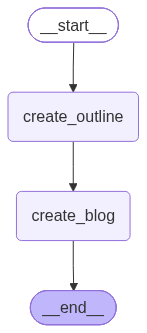

In [10]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())